<a href="https://colab.research.google.com/github/simulate111/Acquisition-and-Analysis-of-Biosignals/blob/main/dtek0042_exercise_4_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DTEK0042 Exercise 4
    Name:
    email:

*** Note for Google Colab Users ***
     Because Google Colab doesn't have a button to convert your notebook to .html format here is a quick work around:
   1. open a new google colab notebook
   2. in the files section in google colab, upload the .ipynb file you want to be converted to .html
   3. in your new open notebook run this command in an empty cell: !jupyter nbconvert --to html YourFileName.ipynb
   4. after the command is finished running refresh the page
   5. In your files section you should see your original .ipynb file that you uploaded and then a .html file of that same notebook.
   6. download the .html file and you're good to go!

In this exercise, you are required to analyze a SCG signal step-by-step as outlined below.  The deliverables for this exercise are a jupyter notebook and a .html file exported form the notebook. The notebook should includes your code, observations, graphs, and conclusions made upon analyzing the given SCG signals. Please provide caption and description for every figure.

## 1- library Imports

In [1]:
#scipy imports
#import scipy
from scipy import signal,stats
#from scipy.signal import butter, filtfilt, freqz

#numpy imports
import numpy as np

#matplotlib imports
import matplotlib.pyplot as plt

#sklean imports
from sklearn.decomposition import PCA
from sklearn import preprocessing as prep
#other imports
from glob import glob

# Data Import
* Load the .txt files of SCG data that are stored in the folder named “dataset” into your python environment.  
* For each .txt data file, select the 3rd column which contains the Z-axis of the SCG signals.
* Note: the sampling frequency of this signal is 200 Hz.

        Hint:  
        * to automate the loading process you can get a list of all data file paths using glob package and subsequently load the files in a for loop.
        
        * dataFiles = glob.glob(path_to_dataset) to get a list of file paths of "dataset\xxdata.txt"
        
         then load the paths one by one in a loop

In [10]:
!git clone https://github.com/simulate111/Acquisition-and-Analysis-of-Biosignals.git

Cloning into 'Acquisition-and-Analysis-of-Biosignals'...
remote: Enumerating objects: 119, done.
remote: Counting objects: 100% (119/119), done.
remote: Compressing objects: 100% (117/117), done.
remote: Total 119 (delta 63), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (119/119), 3.59 MiB | 7.87 MiB/s, done.
Resolving deltas: 100% (63/63), done.


In [16]:
path_to_dataset = "Acquisition-and-Analysis-of-Biosignals/datasetEX4/*.txt"

# Load specific files for plotting later
noisy_sig = np.loadtxt('Acquisition-and-Analysis-of-Biosignals/datasetEX4/Noisy_data_1.txt', usecols=2)
normal_sig = np.loadtxt('Acquisition-and-Analysis-of-Biosignals/datasetEX4/Normal_data_1.txt', usecols=2)

# Get all text files in the directory
dataFiles = glob.glob(path_to_dataset)

data_dict = {}
for file in dataFiles:
    # Load the 3rd column (index 2) of the text file
    data_dict[os.path.basename(file)] = np.loadtxt(file, usecols=2)
### ---------------------- ###

In [19]:
# Define how many data points you want to preview per file
preview_data = {}

# Extract the first 10 rows and all 3 columns from each loaded file
for file_path in dataFiles:
    filename = os.path.basename(file_path)

    # Read the file (all 3 columns) up to the sample size
    df = pd.read_csv(file_path, sep='\s+', header=None, nrows=5)
    df.columns = ['X', 'Y', 'Z']

    # Store the dataframe in the dictionary
    preview_data[filename] = df

# Concatenate into a single DataFrame with MultiIndex columns (Filename -> 3 Columns)
df_preview = pd.concat(preview_data, axis=1)

# Name the index for clarity
df_preview.index.name = 'Sample Index'

# Display the table
df_preview

<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4146/3777595795.py:9: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(file_path, sep='\s+', header=None, nrows=5)


Normal_data_4.txt                     Normal_data_3.txt  \
                             X         Y         Z                 X   
Sample Index                                                           
0                    -0.172974 -1.699875  9.237412          0.261551   
1                    -0.172974 -1.699875  9.237412          0.275925   
2                    -0.172974 -1.795639  9.294876          0.232819   
3                    -0.201706 -1.742966  9.309235          0.228027   
4                    -0.254379 -1.709442  9.304459          0.218460   

                                 Normal_data_1.txt                      \
                     Y         Z                 X         Y         Z   
Sample Index                                                             
0            -3.510483  9.112320          0.237610 -1.255157  9.610306   
1            -3.472183  9.074005          0.290283 -1.259934  9.634262   
2            -3.491333  9.074005          0.271133 -1.269516  9.619888   
3            -3.548798  9.054855          0.256760 -1.226425  9.706085   
4            -3.505707  9.069229          0.261551 -1.240784  9.591156   

             Noisy_data_3.txt  ... Noisy_data_4.txt Noisy_data_1.txt  \
                            X  ...                Z                X   
Sample Index                   ...                                     
0                    0.232819  ...         9.366699         0.409988   
1                    0.223251  ...         9.347549         0.414780   
2                    0.184937  ...         9.400223         0.362106   
3                    0.165802  ...         9.337967         0.395630   
4                    0.151428  ...         9.347549         0.357315   

                                 Normal_data_2.txt                      \
                     Y         Z                 X         Y         Z   
Sample Index                                                             
0            -1.073196  9.725235          1.244369 -1.642410  9.409790   
1            -1.087555  9.787491          1.253952 -1.642410  9.390640   
2            -1.097138  9.792267          1.249161 -1.680725  9.361908   
3            -0.991791  9.710876          1.268310 -1.680725  9.314026   
4            -0.953476  9.730026          1.287476 -1.714233  9.314026   

             Noisy_data_2.txt                      
                            X         Y         Z  
Sample Index                                       
0                    1.033676 -2.255325  9.232620  
1                    1.043259 -2.274475  8.993210  
2                    1.028900 -2.217026  9.237412  
3                    1.052841 -2.245743  8.930954  
4                    1.100723 -2.260117  8.964478  

[5 rows x 24 columns]

In [20]:
fs=200 #samp freq


# Noisy Vs Normal Plotting

* Plot the z-axis SCG signal from the file "Noisy_data_1.txt" and plot the z-axis SCG signal from the file "Normal_data_1.txt"
* Describe your observations and how the plots differ from one another.


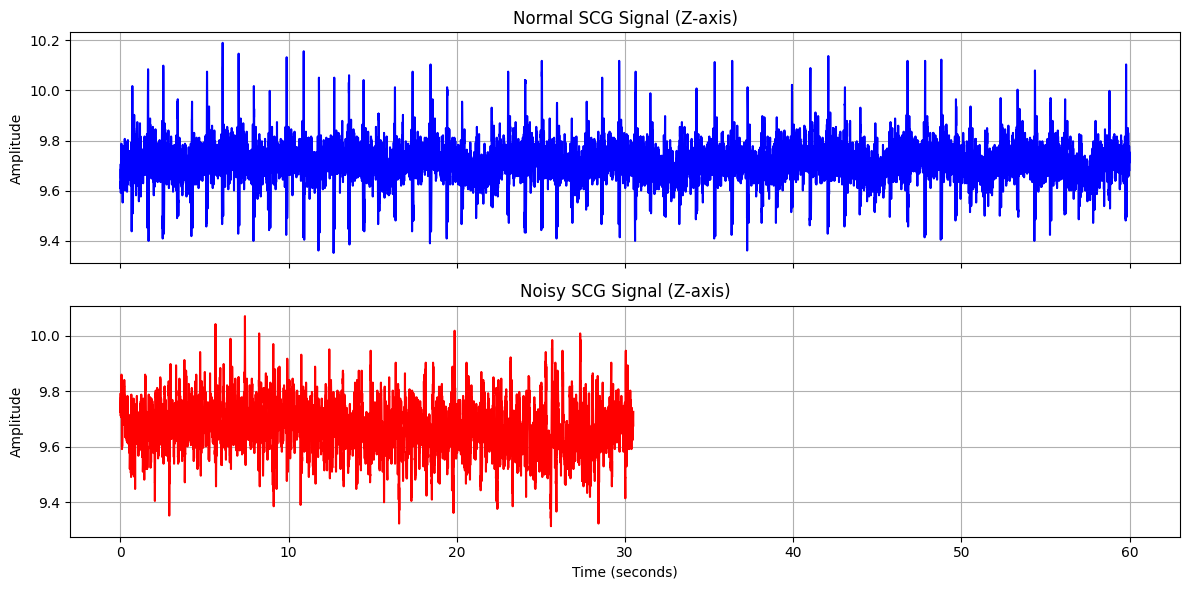

In [24]:
# Create time arrays for both signals (in seconds)
t_noisy = np.arange(len(noisy_sig)) / fs
t_normal = np.arange(len(normal_sig)) / fs

# Create a figure with two subplots
fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Plot Normal Signal
axs[0].plot(t_normal, normal_sig, color='blue')
axs[0].set_title('Normal SCG Signal (Z-axis)')
axs[0].set_ylabel('Amplitude')
axs[0].grid(True)

# Plot Noisy Signal
axs[1].plot(t_noisy, noisy_sig, color='red')
axs[1].set_title('Noisy SCG Signal (Z-axis)')
axs[1].set_xlabel('Time (seconds)')
axs[1].set_ylabel('Amplitude')
axs[1].grid(True)

plt.tight_layout()
plt.show()

Based on the plots, the following differences can be observed:

* **Periodicity and Rhythm:** The **Normal SCG** signal displays clear, regular, and repeating spikes that represent distinct cardiac cycles. In contrast, the **Noisy SCG** signal lacks this recognizable rhythm; the regular peaks are obscured by erratic, dense fluctuations.

* **Signal Clarity:** Individual beats are easily distinguishable in the normal signal. In the noisy signal, the data is highly distorted, effectively masking the underlying heartbeats.

* **Data Duration:** The plotted normal signal spans a full 60 seconds, whereas the noisy signal data is much shorter, ending just after the 30-second mark.

* **Amplitude Features:** The normal signal features sharp, prominent peaks extending up to approximately 10.2 and down to 9.4. The noisy signal's variations are more tightly packed and erratic, lacking those isolated, well-defined maximum and minimum peaks.

# Data Segmentation
* Here is a simple function to use for data segmentation
* Segment the Z-axis signals into 5-second segments
* The sampling frequency used to record these signals is 200 Hz.
* Store the segments and the accompanying labels

In [25]:
#code (provided)

def _slicing(sig, file_label, segment_length = 1000):

    """
    inputs:
    sig : input array to be segmented
    file_label : label to be applied to segmented signal
    segment_length : Length in samples of the segments produced from the input signal

    outputs:
    sig_sliced : a list of segments
    label : a list of corresponding labels for the segmented signal

    """

    sig_sliced = []
    label = []

    # slicing

    for i in np.arange(int(len(sig)/segment_length)):

        sig_sliced.append( sig[i*segment_length:(i+1)*segment_length] )

        label.append(file_label)

    return (sig_sliced , label)

# Feature Extraction Function Creation
*  Define a function and name it “feature_extraction” in which you compute and return the features listed below
    * *Time Domain Features*:  mean, standard deviation, interquartile-range, median, peak-to-peak range, skewness, kurtosis, and root mean square.
    * *Frequency Domain Features*: power spectral density (using welch function of scipy)
    
        * For power spectral density, Calculate the total power spectral density within frequency bins of 4 Hz steps. Discard the frequencies above 40 Hz. Get the power within each bin.
    
        Hint:
        
        Reference: https://docs.scipy.org/doc/scipy/reference/stats.html for skewness, kurtosis, interquartile-range(iqr)
        
        Reference: https://numpy.org/doc/stable/reference/routines.statistics.html for other time domain features
        
        Reference: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.scale.html for transforming to zero mean and unit variance



In [27]:
import numpy as np
from scipy import signal
from scipy.stats import iqr, skew, kurtosis
from sklearn.preprocessing import scale

def feature_extraction(sig, fs = 200):

    """
    inputs:
    sig : input array to extract features from
    fs : sampling frequency of input array

    outputs:
    feature_array: an array containing all the features extracted from the signal
    """

    ########################################## statistical features - time domain

    f_mean = np.mean(sig)
    f_std = np.std(sig)
    f_iqr = iqr(sig)
    f_median = np.median(sig)
    f_ptp = np.ptp(sig)
    f_skew = skew(sig)
    f_kurtosis = kurtosis(sig)
    f_rms = np.sqrt(np.mean(sig**2))

    time_features = [f_mean, f_std, f_iqr, f_median, f_ptp, f_skew, f_kurtosis, f_rms]

    ########################################## PSD

    # transforming to zero mean and unit variance -- only do this when extracting PSD
    # Hint: transfromed_sig = function_for_scale(sig)
    transformed_sig = scale(sig)

    frequencies , PSD = signal.welch(transformed_sig, fs=fs)

    freqs_arr = np.arange(0,41,4)

    PSD_binned_sum = []

    for i in range(freqs_arr.shape[0]-1):

        PSD_binned_sum.append (np.sum(PSD[np.where( (frequencies >= freqs_arr[i] ) &
                                                   ( frequencies < freqs_arr[i+1] ) )]) )

    # return the feature array
    feature_array = time_features + PSD_binned_sum

    return feature_array

In [ ]:
#code
def feature_extraction(sig, fs = 200):


    """
    inputs:
    sig : input array to extract features from
    fs : sampling frequency of input array


    outputs:
    feature_array: an array containing all the features extracted from the signal
    """


    ########################################## statistical features - time domain





    ########################################## PSD

    # transforming to zero mean and unit variance -- only do this when extracting PSD
    # Hint: transfromed_sig = function_for_scale(sig)

    frequencies , PSD = signal.welch()

    freqs_arr = np.arange(0,41,4)

    PSD_binned_sum = []

    for i in range(freqs_arr.shape[0]-1):

        PSD_binned_sum.append (np.sum(PSD[np.where( (frequencies >= freqs_arr[i] ) &
                                                   ( frequencies < freqs_arr[i+1] ) )]) )


    # return the feature array



# Feature Extraction Application

* You must first segment your signals and then extract features from each segment. You could do it in the following way:



* Call the _slicing function to section all the z-axis data into 5-second segments
        Hint: Load each file in "dataFiles" with for-loop
* Use the feature extraction function you created and extract features from every segment that you have obtained.
* Store the labels and the features you extracted from each segment to numpy arrays.
        Hint: Think of an easy way to extract the label "noisy" or "normal" from each file name
        str.split() could be used somehow in this case

In [28]:
import os
import numpy as np

# Initialize lists to store the extracted features and corresponding labels
features_list = []
labels_list = []

# Segment length for 5 seconds at 200 Hz
seg_length = 5 * 200

# Loop through all files in the dataset
for file_path in dataFiles:

    # Extract the filename from the full path
    filename = os.path.basename(file_path)

    # Extract the label ("Noisy" or "Normal") from the filename
    # Splitting "Noisy_data_1.txt" by '_' gives ['Noisy', 'data', '1.txt']
    label_str = filename.split('_')[0].lower()

    # Load the Z-axis signal (3rd column, index 2)
    sig = np.loadtxt(file_path, usecols=2)

    # Segment the signal using the defined _slicing function
    segments, segment_labels = _slicing(sig, file_label=label_str, segment_length=seg_length)

    # Loop through each extracted segment
    for i in range(len(segments)):
        current_segment = segments[i]
        current_label = segment_labels[i]

        # Extract features from the current segment
        extracted_features = feature_extraction(current_segment, fs=200)

        # Store the features and label
        features_list.append(extracted_features)
        labels_list.append(current_label)

# Convert the lists to numpy arrays as requested
X_features = np.array(features_list)
y_labels = np.array(labels_list)

# Optional: Print the shapes to verify the results
print(f"Shape of feature array (X): {X_features.shape}")
print(f"Shape of labels array (y): {y_labels.shape}")

Shape of feature array (X): (75, 18)
Shape of labels array (y): (75,)


# Standardize Features
Hint:

    Use sklearn.preprocessing.scale() to standardize the features
    Reference: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.scale.html

In [29]:
from sklearn.preprocessing import scale

# Standardize the feature array (centers to the mean and scales to unit variance)
X_features_scaled = scale(X_features)

# Optional: Verify the standardization (mean should be approx 0, std approx 1)
print(f"Mean of first feature after scaling: {np.mean(X_features_scaled[:, 0]):.4f}")
print(f"Std deviation of first feature after scaling: {np.std(X_features_scaled[:, 0]):.4f}")

Mean of first feature after scaling: 0.0000
Std deviation of first feature after scaling: 1.0000


# Principal Component Analysis
* Principal Component Analysis (PCA) is used to reduce the dimensionality of a data set consisting of many variables correlated with each other. This can then be used to visualize the data in a more practical way.
* Compute the first and 2nd principal components
* Plot the two components on a scatter plot with the coloring done by label
* Are these features useful to seperate the two types of signals (noisy vs normal)?
* Describe your observations.
    
        Hint:
        my_pca=PCA(n_components=2)
        pca_out = my_pca.fit_transform(input)

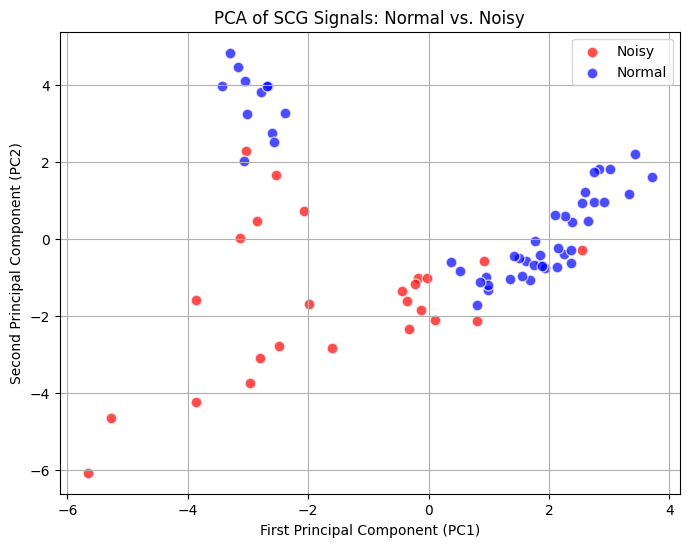

In [30]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Compute the first and 2nd principal components using the standardized features
my_pca = PCA(n_components=2)
pca_out = my_pca.fit_transform(X_features_scaled)

# Plot the two components on a scatter plot colored by label
plt.figure(figsize=(8, 6))

# Define colors for the labels
colors = {'normal': 'blue', 'noisy': 'red'}
unique_labels = np.unique(y_labels)

# Iterate through the unique labels to plot them and build the legend
for label in unique_labels:
    # Find the indices where the label matches
    idx = np.where(y_labels == label)

    # Scatter plot for the current label
    plt.scatter(pca_out[idx, 0], pca_out[idx, 1],
                c=colors.get(label, 'black'),
                label=label.capitalize(),
                alpha=0.7, edgecolors='w', s=60)

plt.title('PCA of SCG Signals: Normal vs. Noisy')
plt.xlabel('First Principal Component (PC1)')
plt.ylabel('Second Principal Component (PC2)')
plt.legend()
plt.grid(True)
plt.show()

# Observations

### Observations: PCA of SCG Signals

Based on the PCA scatter plot, here are the observations:

*   **Data Spread and Clustering:** The Normal signals (blue dots) generally form two separate groupings: a tight cluster in the upper-left quadrant and a more dispersed, upward-trending cluster stretching toward the right side of the plot. The Noisy signals (red dots) are much more widely scattered and show higher variance, primarily occupying the lower and leftmost regions of the plot.

*   **Separability (Feature Usefulness):** The extracted features show moderate usefulness for separating the signals. While there are distinct zones dominated by either normal or noisy data, the separation is not perfect. There is noticeable overlap, particularly around the center of the plot (near PC1 = 0, PC2 = -1) and slightly in the upper-left cluster, where a few noisy data points mingle with the normal ones.

*   **Conclusion:** The features successfully capture underlying differences in the variance of the two signal types, but a simple linear boundary in this 2D PCA space would result in some misclassifications due to the overlapping regions.